# Proyek Klasifikasi Gambar: [Melanoma skin cancer]

<h2>Import Library <hr>

In [ ]:
import shutil
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import splitfolders

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
import tensorflowjs as tfjs
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
np.random.seed(42)
tf.random.set_seed(42)

<h2>Data Loading<hr>

In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

input_folder = "/content/drive/MyDrive/dataset"
output_folder = "/content/drive/MyDrive/dataset_split"

# cek input folder
if not os.path.exists(input_folder):
    raise Exception("Dataset input tidak ditemukan!")

# hapus hasil split lama
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

# split dataset
splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15),
    group_prefix=None
)

# cek hasil split
for folder in ["train", "val", "test"]:
    path = os.path.join(output_folder, folder)
    print(f"\nFolder: {folder}")

    for label in os.listdir(path):
        label_path = os.path.join(path, label)

        if os.path.isdir(label_path):
            print(label, ":", len(os.listdir(label_path)), "images")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Copying files: 10605 files [04:16, 41.41 files/s]



Folder: train
benign : 3849 images
malignant : 3573 images

Folder: val
benign : 825 images
malignant : 765 images

Folder: test
benign : 826 images
malignant : 767 images


In [3]:
# Akses dataset hasil split
dataset_path = "/content/drive/MyDrive/dataset_split"
train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")
test_path = os.path.join(dataset_path, "test")

# Cek struktur folder dan jumlah data
for folder in ["train", "val", "test"]:
    print(f"\nFolder: {folder}")

    path = os.path.join(dataset_path, folder)

    # cek apakah folder ada
    if not os.path.exists(path):
        print(f"Folder {folder} tidak ditemukan!")
        continue

    total_images = 0

    for label in os.listdir(path):
        label_path = os.path.join(path, label)

        # pastikan hanya membaca folder class
        if os.path.isdir(label_path):
            jumlah_gambar = len(os.listdir(label_path))
            total_images += jumlah_gambar

            print(f"{label}: {jumlah_gambar} gambar")

    print(f"Total gambar pada folder {folder}: {total_images}")


Folder: train
benign: 3849 gambar
malignant: 3573 gambar
Total gambar pada folder train: 7422

Folder: val
benign: 825 gambar
malignant: 765 gambar
Total gambar pada folder val: 1590

Folder: test
benign: 826 gambar
malignant: 767 gambar
Total gambar pada folder test: 1593


In [4]:
# Melihat ukuran resolusi gambar
def print_images_resolution(directory):
    unique_sizes = set() # menyimpan ukuran gambar unik (tidak ada duplikat)
    total_images = 0 # untuk menghitung total gambar dari semua kelas

    for subdir in os.listdir(directory): # looping semua kelas
        subdir_path = os.path.join(directory, subdir) # buat path folder kelas
        image_files = os.listdir(subdir_path) # ambil semua isi folder dalam kelas
        num_images = len(image_files) # hitung jumlah gambar per kelas

        print(f"{subdir}: {num_images}") # menampilkan jumlah gambar perkelas
        total_images += num_images # tambah ke total

        for img_file in image_files: # loop tiap gambar
            img_path = os.path.join(subdir_path, img_file) # buat path lengkap
            with Image.open(img_path) as img: # buka gambar
                unique_sizes.add(img.size) # ambil ukuran gambar

        for size in unique_sizes: # menampilkan ukuran unik
            print(f"- {size}")
        print("----------------")

    print(f"\nTotal data train: {total_images}") # menampilkan total gambar

print_images_resolution(train_path)

benign: 3849
- (300, 300)
----------------
malignant: 3573
- (300, 300)
----------------

Total data train: 7422


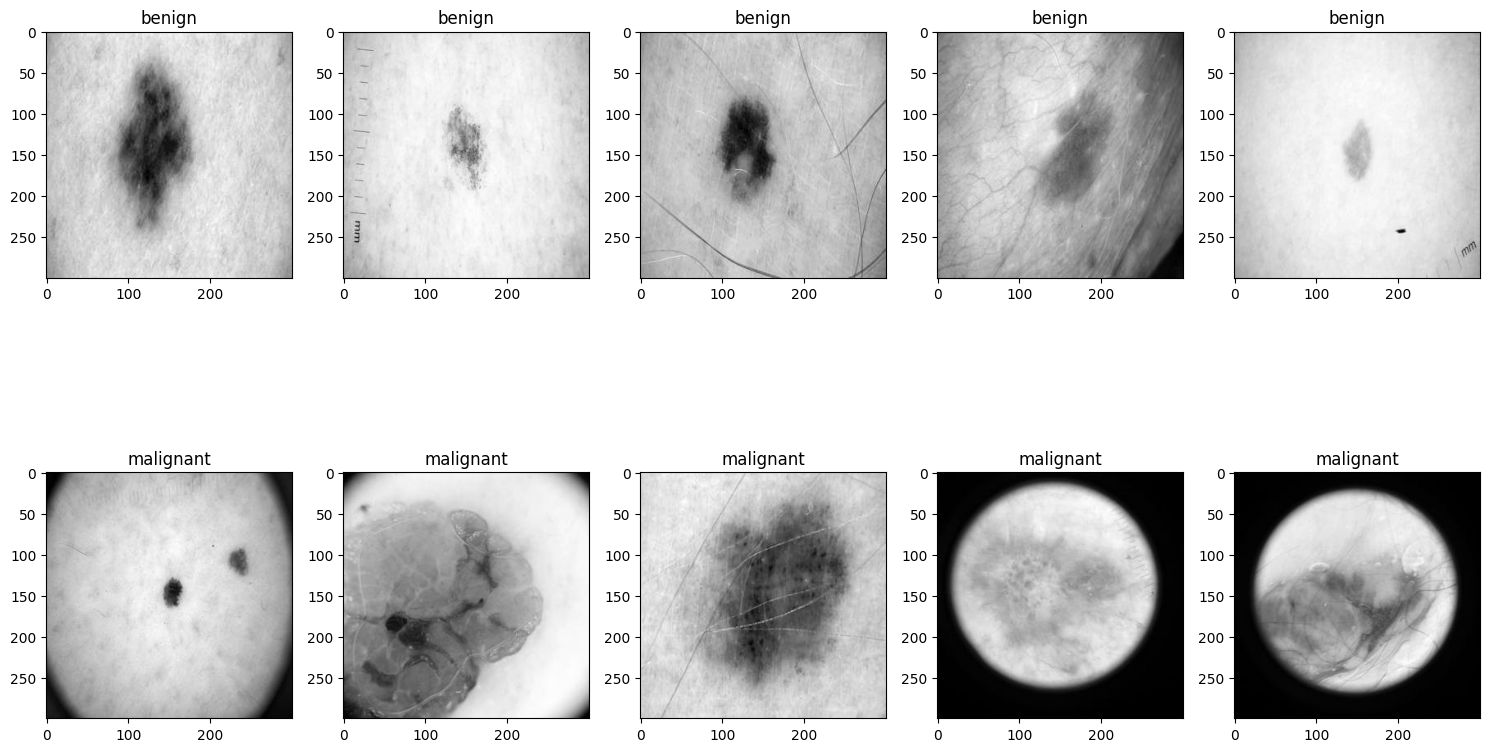

In [5]:
# Membuat kamus untuk menyimpan gambar untuk setiap kelas dalam data
cancer_image = {}

# Ambil semua class folder train
for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name) # buat path tiap kelas

    # pastikan hanya folder
    if os.path.isdir(class_path):
        cancer_image[class_name] = os.listdir(class_path) # mengambil semua nama file gambar

# Plot gambar
fig, axs = plt.subplots(len(cancer_image.keys()), 5, figsize=(15, 10))

for i, class_name in enumerate(cancer_image.keys()): # looping untuk tiap kelas

    images = np.random.choice(cancer_image[class_name], 5, replace=False) # pilih 5 gambar secara acak setiap run

    for j, image_name in enumerate(images): # loop tampilan gambar
        img_path = os.path.join(train_path, class_name, image_name) # path gambar
        img = Image.open(img_path).convert("L")  # buka gambar dan ubah ke grayscale
        axs[i, j].imshow(img, cmap="gray") # tampilkan gambar posisi baris[i] kelas[j]
        axs[i, j].set_title(class_name) # tanbah judul kelas

plt.tight_layout()
plt.show()

<h2>Data Preprocessing<hr>

In [6]:
# parameter gambar
IMG_SIZE = (224, 224) # resize gambar menjadi 224,224
BATCH_SIZE = 32 # batch size

# train generator dengan augmentasi data
train_datagen = ImageDataGenerator(
    rescale=1./255, # normalisasi piksel 0-1
    rotation_range=10, # rotasi 10 derajat
    width_shift_range=0.1, # geser horizontal
    height_shift_range=0.1, # geser vertikal
    horizontal_flip=True, # flip horizontal
    zoom_range=0.1, # perbesar
)

# val generator
val_datagen = ImageDataGenerator(rescale=1./255) # normalisasi pixel menjadi 0-1

# test generator
test_datagen = ImageDataGenerator(rescale=1./255) # normalisasi pixel menjadi 0-1

# load train set
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode="binary",
    seed=42 # mengunci pola shufle agar konsisten
)

# load validation set
val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode="binary",
    shuffle=False, # val data tidak di acak karna saat evaluasi butuh urutan
    seed=42
)

# load test set
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode="binary",
    shuffle=False # test data tidak di acak karna saat evaluasi butuh urutan
)

Found 7422 images belonging to 2 classes.
Found 1590 images belonging to 2 classes.
Found 1593 images belonging to 2 classes.


In [7]:
# Verifikasi mapping kelas
print("Label mapping:", train_generator.class_indices) # lebeling kelas
print(f"Train samples   : {train_generator.samples}") # menghitung jumlah data train
print(f"Val samples     : {val_generator.samples}") # menghitung jumlah data validation
print(f"Test samples    : {test_generator.samples}") # menghitung jumlah data test
print(f"Jumlah kelas    : {train_generator.num_classes}") # menghitung jumlah kelas

Label mapping: {'benign': 0, 'malignant': 1}
Train samples   : 7422
Val samples     : 1590
Test samples    : 1593
Jumlah kelas    : 2


In [8]:
# menghitung bobot tiap kelas
class_weights = compute_class_weight(
    class_weight='balanced', # menghindari bias ke kelas mayoritas
    classes=np.unique(train_generator.classes), # mengambil label kelas unik dari data train
    y=train_generator.classes # labeling data training
)

class_weight_dict = dict(enumerate(class_weights)) # ubah ke dalam bentuk dict
print("class_wights:", class_weight_dict)

class_wights: {0: np.float64(0.9641465315666407), 1: np.float64(1.038623005877414)}


<h2>Modelling<hr>

In [9]:
# inisialisasi model sequential
model = Sequential()

# convolution layer 1
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3))) # 32 filter, 3,3 ukuran kernel, ukuran gambar selalu tetap, fungsi aktivasi 'relu', input grayscale
model.add(BatchNormalization()) # stabilin proses training
model.add(MaxPooling2D(2, 2)) # mengecilkan ukuran feature map

# convolution layer 2
model.add(Conv2D(64, (3, 3), padding='same', activation='relu')) # 64 filter, 3,3 ukuran kernel , ukuran gambar selalu tetap, fungsi aktivasi 'relu'
model.add(BatchNormalization()) # stabilin proses training
model.add(MaxPooling2D(2, 2)) # mengecilkan ukuran feature map

# convolution layer 3
model.add(Conv2D(128, (3, 3), padding='same', activation='relu')) # 128 filter, 3,3 ukuran kernel , ukuran gambar selalu tetap, fungsi aktivasi '
model.add(BatchNormalization()) # stabilin proses training
model.add(MaxPooling2D(2, 2)) # mengecilkan ukuran feature map

model.add(GlobalAveragePooling2D()) # mengubah feature map menjadi vector

# fully connected layer
# dense layer 1
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001))) # 128 neuron, fungsi aktivasi 'relu', regularisasi untuk membantu overfit
model.add(Dropout(0.5)) # mematikan 50% neuron saat training

# dense layer 2
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001))) # 64 neuron, fungsi aktivasi 'relu', regularisasi untuk membantu overfit
model.add(Dropout(0.3)) # mematikan 30% neuron saat training

# output layer
model.add(Dense(1, activation='sigmoid')) # sigmoid untuk binary clasification

# compile model untuk training
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0001), # menggunakan optimizer adamw untuk update bobot
    loss='binary_crossentropy', # loss fungtion untuk binary classification
    # evaluasi performa model
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc") # kualitas klasifikasi model
        ]
    )

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,977 (464.75 KB)

 Trainable params: 118,529 (463.00 KB)

 Non-trainable params: 448 (1.75 KB)

None


In [10]:
# membuat callback untuk menghentikan otomatis jika training tidak membaik
early_stopping = EarlyStopping(
    monitor='val_loss', # melihat dari val_loss
    mode='min', # memilih minimum val_loss
    patience=5, # training akan berhenti jika 5 epoch berturut turut tidak membaik
    restore_best_weights=True, # model akan kembali ke epoch terbaik
    verbose=1 # menampilkan log proses di output
)

# membuat callback untuk menyimpan model terbaik
model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras', # nama file model yang akan di simpan
    monitor='val_loss', # melihat dari val_loss
    mode='min', # memilih minimum val_loss
    save_best_only=True, # hanya menyimpan model terbaik
    verbose=1 # menampilkan log proses di output
)

# membuat callback menurunkan learning rate otomatis
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', # melihat dari val_loss
    mode='min', # memilih minimum val_loss
    factor=0.3, # learning rate diperkecil, misal 0.001 x 0.3 jadi 0.0003
    patience=3, # jika selama 3 epoch tidak membaik lr diturunkan
    min_lr=1e-6, # batas minimum lr
    verbose=1 # menampilkan log proses di output
)

In [11]:
# proses training model hasilnya di simpan kedalam history
history = model.fit(
    train_generator, # data yang dipakai untuk melatih model
    epochs=50, # jumlah epoch
    validation_data=val_generator, # data evaluasi untuk cek performa tiap epoch
    class_weight=class_weight_dict, # memberikan bobot berbeda untuk tiap kelas
    # fungsi untuk kontrol training: earlystop untuk stop training mencegah overfit, modelcheck untuk simpan model terbaik, recucelr untuk menurunkan learning rate agar ga stuck
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 1/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.7714 - auc: 0.8395 - loss: 0.7073 - precision: 0.7743 - recall: 0.7301
Epoch 1: val_loss improved from None to 0.80537, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
232/232 ━━━━━━━━━━━━━━━━━━━━ 160s 640ms/step - accuracy: 0.8022 - auc: 0.8729 - loss: 0.6615 - precision: 0.7999 - recall: 0.7856 - val_accuracy: 0.6509 - val_auc: 0.8936 - val_loss: 0.8054 - val_precision: 0.9412 - val_recall: 0.2928 - learning_rate: 1.0000e-04
Epoch 2/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.8367 - auc: 0.9088 - loss: 0.5912 - precision: 0.8230 - recall: 0.8398
Epoch 2: val_loss improved from 0.80537 to 0.60305, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
232/232 ━━━━━━━━━━━━━━━━━━━━ 139s 598ms/step - accuracy: 0.8368 - auc: 0.9097 - loss: 0.5878 - precision: 0.8262 - recall: 0.8371 - val_accuracy: 0.8258 - val_auc: 0.9299 - val_loss: 0.603

<h2>Evaluasi dan Visualisasi<hr>

In [12]:
best_epoch = np.argmax(history.history['val_accuracy']) # mencari epoch terbaik berdasarkan 'val_accuracy'

train_acc = history.history['accuracy'][best_epoch] # mengambil training accuracy pada best epoch
val_acc = history.history['val_accuracy'][best_epoch] # mengambil training val_accuracy pada best epoch

test_loss, test_acc, test_prec, test_rec, test_auc = model.evaluate(test_generator) # evaluasi model di test set

# menampilkan hasil akurasi train, val, test
print("==============================")
print("FINAL EVALUATION RESULT")
print("==============================")
print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Test Precision      : {test_prec:.4f}")
print(f"Test Recall         : {test_rec:.4f}")
print(f"Test AUC            : {test_auc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 180ms/step - accuracy: 0.9146 - auc: 0.9730 - loss: 0.3505 - precision: 0.9352 - recall: 0.8840
FINAL EVALUATION RESULT
Train Accuracy      : 0.9000
Validation Accuracy : 0.8969
Test Accuracy       : 0.9146
Test Precision      : 0.9352
Test Recall         : 0.8840
Test AUC            : 0.9730


In [13]:
test_generator.reset() # mengembalikan generator ke posisi awal

y_pred_prob = model.predict(test_generator) # prediksi probabilitas model
y_pred = (y_pred_prob > 0.5).astype(int).flatten() # konversi probabilitas ke kelas jika lebih dari 5 kelas 1(melignant) dan sebaliknya, lalu ubah menjadi nilai true/false dan ubah bentuknya menjadi array 1 dimensi
y_true = test_generator.classes # ambil label asli

class_names = list(test_generator.class_indices.keys()) # ambil nama kelas

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=class_names)) # menampilkan clasification report dari data asli dan prediksi berdasarkan kelas

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step
Classification report:
              precision    recall  f1-score   support

      benign       0.90      0.94      0.92       826
   malignant       0.94      0.88      0.91       767

    accuracy                           0.91      1593
   macro avg       0.92      0.91      0.91      1593
weighted avg       0.92      0.91      0.91      1593



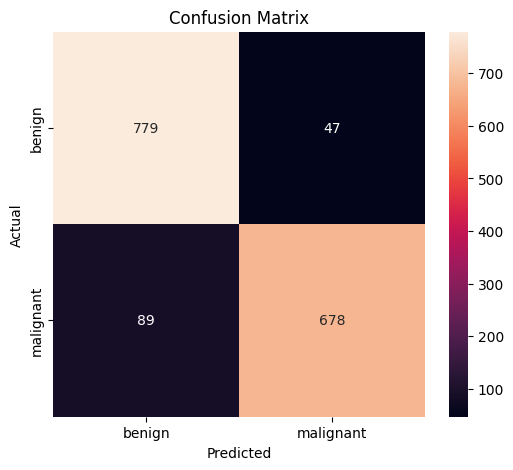

In [14]:
# buat confusion matrix tabel heatmap
cm = confusion_matrix(y_true, y_pred) # confusion matriks = y_true:data asli, y_pred:data prediksi

# menampilkan plot heatmap confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

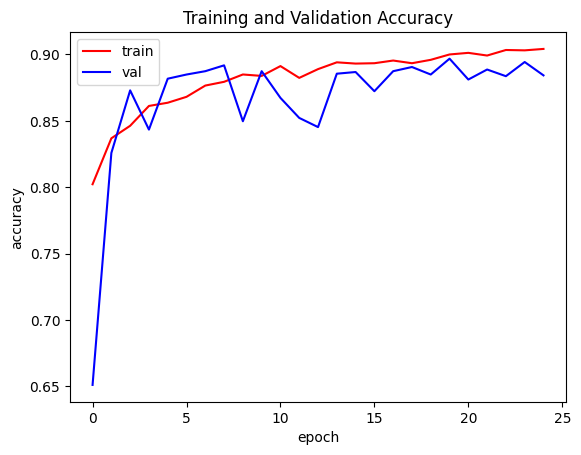

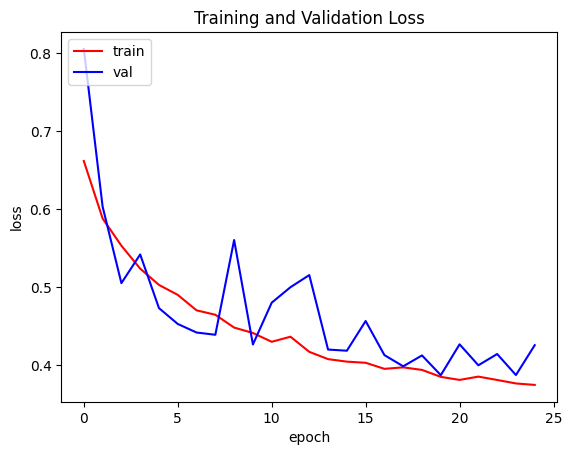

In [15]:
# ambil data training dari histori
acc = history.history['accuracy'] # ambil training accuracy
val_acc = history.history['val_accuracy'] # ambil training val_accuracy
loss = history.history['loss'] # ambil training loss
val_loss = history.history['val_loss'] # ambil training val_loss

epochs = range(len(acc)) # membuat list index sepanjang jumlah training epoch

# plot accuracy
plt.plot(epochs, acc, 'r', label='train') # training akurasi garis merah
plt.plot(epochs, val_acc, 'b', label='val') # training validasi akurasi garis biru
plt.title('Training and Validation Accuracy') # judul graf
plt.ylabel('accuracy') # label vertical
plt.xlabel('epoch') # label horizontal
plt.legend(loc='upper left') # keterangan acc/val di atas kiri
plt.show()

# plot loss
plt.plot(epochs, loss, 'r', label='train') # training akurasi garis merah
plt.plot(epochs, val_loss, 'b', label='val') # training akurasi garis merah
plt.title('Training and Validation Loss') # judul graf
plt.ylabel('loss') # label vertikal
plt.xlabel('epoch') # label horizontal
plt.legend(loc='upper left') # keterangan loss/val di atas kiri
plt.show()

<h2>Konversi model<hr>

In [17]:
model = tf.keras.models.load_model('best_model.keras') # Load model terbaik hasil training

os.makedirs('tfjs_model', exist_ok=True) # bauat folder tfjs_model untuk lokasi file tfjs
os.makedirs('tflite', exist_ok=True) # bauat folder tfjs_model untuk lokasi file tflite
os.makedirs('saved_model', exist_ok=True) # bauat folder tfjs_model untuk lokasi file tfserving

# model tf serving
saved_model_path = 'saved_model'
model.export(saved_model_path) # mengubah model ke format save model

print(f"SavedModel tersimpan di: {saved_model_path}") # print lokasi file tf serving

# model tflite
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path) # mengambil savemodel untuk dikonversi ke format mobile

converter.optimizations = [tf.lite.Optimize.DEFAULT] # optimasi ukuran model

tflite_model = converter.convert() # proses konversi ke tflite

tflite_path = 'tflite/model.tflite' # lokasi file hasil konversi
with open(tflite_path, 'wb') as f: # menyimpan model ke file binary
    f.write(tflite_model)

print(f"TFLite tersimpan di: {tflite_path}") # print lokasi file tflite

# menyimpan label kelas
class_names = ['benign', 'malignant']

label_path = 'tflite/label.txt' # lokasi file label
with open(label_path, 'w') as f: # simpan label ke file label
    f.write('\n'.join(class_names))

print(f"Label tersimpan di: {label_path}") # print lokasi file label

# model tfjs
tfjs.converters.save_keras_model(model, 'tfjs_model') # konversi model kedalam format web (json, bin)

print("TensorFlow.js tersimpan di: tfjs_model/") # print lokasi file tfjs

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136205158419344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136205210490192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136205197306256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136205197311248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136205158416464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136205210492688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136208152417808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136205245572752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136205197309328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136205197303952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136205197311440: Ten

TFLite tersimpan di: tflite/model.tflite
Label tersimpan di: tflite/label.txt
failed to lookup keras version from the file,
    this is likely a weight only file
TensorFlow.js tersimpan di: tfjs_model/
